# Fig 2f colormap trials

Export **Fig 2f** (lizard head-stationary), **mouse Fig 2f**, and **Fig S3** (still vs moving), each in four colormap variants:

| Variant | Description |
|---|---|
| `paper_white0` | Published style — turbo with zero mapped to white |
| `turbo` | Matplotlib turbo |
| `hot` | Matplotlib hot (black → red → yellow → white; no white at zero) |
Export **Fig 2f** (lizard head-stationary), **mouse Fig 2f**, and **Fig S3** (still vs moving), each in four colormap variants:

| Variant | Description |
|---|---|
| `paper_white0` | Published style — turbo with zero mapped to white |
| `turbo` | Matplotlib turbo |
| `hot` | Matplotlib hot (black → red → yellow → white; no white at zero) |
| `hot_r` | Reversed hot (white → yellow → red → black) |

**Output root:** `outputs/2f_colormap_trials/` (empty `TAG`) or `outputs/2f_colormap_trials_<tag>_<date>_<time>/`.

Each figure is a self-contained plot bundle: `plots/`, `metadata/` (pickle + params + cohort), `LOGIC.md`, and `replot.py`.

## 0. Setup

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

plt.ioff()

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "eye_tracking_system_tools").is_dir():
            REPO = p
            break

sys.path.insert(0, str(REPO / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from eye_tracking_system_tools.analysis.block_registry import load_registry
from eye_tracking_system_tools.analysis.event_cache import (
    build_or_load_event_tables,
    ensure_traces_for_blocks,
)
from eye_tracking_system_tools.analysis.export_meta import load_params_yaml
from eye_tracking_system_tools.analysis.figures_2f_colormap_export import (
    COLORMAP_VARIANTS,
    colormap_trials_run_dir,
    export_2f_colormap_bundle,
    verify_colormap_trials_run,
)

# Empty TAG → outputs/2f_colormap_trials (overwrite working folder)
TAG = ""

LIZARD_REGISTRY = REPO / "configs" / "paper_blocks.yaml"
LIZARD_PARAMS = REPO / "configs" / "analysis_params.yaml"
MOUSE_REGISTRY = REPO / "configs" / "mouse_M_002_blocks.yaml"
MOUSE_PARAMS = REPO / "configs" / "analysis_params_mouse.yaml"

RUN = colormap_trials_run_dir(REPO / "outputs", TAG)
CACHE_DIR = RUN / "metadata" / "event_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("REPO:", REPO)
print("RUN :", RUN)
print("Colormap variants:", ", ".join(COLORMAP_VARIANTS))

REPO: /Users/nimi/Projects/PETS
RUN : /Users/nimi/Projects/PETS/outputs/2f_colormap_trials
Colormap variants: paper_white0, turbo, hot, hot_r


## 1. Load lizard event tables (+ traces for Fig 2f / S3)

In [2]:
lizard_params = load_params_yaml(LIZARD_PARAMS)
lizard_specs = load_registry(LIZARD_REGISTRY)
lizard_tables, lizard_cache, lizard_from_cache = build_or_load_event_tables(
    lizard_specs,
    lizard_params,
    CACHE_DIR,
    keep_traces=True,
    prefer_finalized=True,
)
block_keys = [b.spec.block_key for b in lizard_tables.blocks]
lizard_tables = ensure_traces_for_blocks(lizard_tables, block_keys)
print(
    f"lizard blocks={len(lizard_tables.blocks)} events={len(lizard_tables.all_saccades)} "
    f"cache={'hit' if lizard_from_cache else 'miss'}"
)
print(lizard_cache)

[PV_106_block_008] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_009] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_010] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_011] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_012] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_143_block_001] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_143_block_002] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)

## 1b. Head-movement labels + turbo Fig 2f (head-stationary where labeled)

Each saccade row in `EventTables.all_saccades` can carry a **`head_movement`** boolean:

- **Source:** `lizMov.mat` under each block's `oe_files/` tree (Mark's lizard movement analysis). At detection/finalize time, `label_saccades_head_movement()` sets `True` when any movement sample falls inside `[saccade_on_ms, saccade_off_ms]`.
- **Fallback:** `analysis/head_movement_events.csv` or `analysis/lizard_movement_events.csv` if present.
- **Missing IMU:** blocks without `lizMov.mat` get `head_movement=NaN` (e.g. some PV_57 blocks).

Fig 2f uses `figure_2f.require_head_stationary: true` → keep only rows with `head_movement == False`. Rows with `NaN` labels are dropped from that filter.

The cells below refresh labels from disk, print per-block diagnostics, then export **turbo only** with the head-stationary filter.


In [3]:
import pandas as pd
from eye_tracking_system_tools.analysis.head_labels import (
    find_lizmov_mat,
    refresh_event_tables_head_labels,
)
from eye_tracking_system_tools.analysis.pipeline import with_params

REFRESH_HEAD_LABELS = True  # re-read lizMov.mat; set False to use cached/finalized column as-is

if REFRESH_HEAD_LABELS:
    lizard_tables = refresh_event_tables_head_labels(lizard_tables)

df = lizard_tables.all_saccades.copy()
if "head_movement" not in df.columns:
    raise RuntimeError("all_saccades has no head_movement column after refresh")

df["block_key"] = [
    f"{a}_block_{str(b).zfill(3)}"
    for a, b in zip(df["animal"].astype(str), df["block"].astype(str))
]

rows = []
for b in lizard_tables.blocks:
    key = b.spec.block_key
    sub = df[df["block_key"] == key]
    liz = find_lizmov_mat(b.spec)
    labeled = sub["head_movement"].notna().sum() if not sub.empty else 0
    rows.append(
        {
            "block_key": key,
            "lizMov.mat": liz is not None,
            "n_events": int(len(sub)),
            "n_labeled": int(labeled),
            "n_still": int((sub["head_movement"] == False).sum()) if labeled else 0,  # noqa: E712
            "n_moving": int((sub["head_movement"] == True).sum()) if labeled else 0,  # noqa: E712
            "n_nan": int(sub["head_movement"].isna().sum()),
        }
    )

head_diag = pd.DataFrame(rows).sort_values("block_key")
print(head_diag.to_string(index=False))
print()
print("Pooled head_movement value counts (all saccade rows):")
print(df["head_movement"].value_counts(dropna=False))

n_before = int(len(df))
n_labeled = int(df["head_movement"].notna().sum())
n_still = int((df["head_movement"] == False).sum())  # noqa: E712
n_moving = int((df["head_movement"] == True).sum())  # noqa: E712
print()
print(f"Before head-stationary filter: {n_before} events")
print(f"  labeled (not NaN): {n_labeled}")
print(f"  still (False):     {n_still}")
print(f"  moving (True):     {n_moving}")
print(f"  unlabeled (NaN): {n_before - n_labeled}")
assert n_labeled > 0, "No head_movement labels found — check lizMov.mat paths"
assert n_moving > 0, "No head-movement events found — filter would not remove anything"
assert n_still < n_before, "Head-stationary filter did not remove any events"
print("OK: head-stationary filter will drop moving + unlabeled rows.")


[PV_106_block_008] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=28251)
[PV_106_block_009] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=13654)
[PV_106_block_010] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=11768)
[PV_106_block_011] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=50801)
[PV_106_block_012] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=20040)
[PV_143_block_001] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=21888)
[PV_143_block_002] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=9045)
[PV_143_block_003] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=22791)
[PV_143_block_004] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=10454)
[PV_62_block_024] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=55275)
[PV_62_block_026] labeled head_movement from lizMov.mat (lizMov.mat; n_mov_samples=54656)
[P

[2f] head_stationary filter: 19212 → 6996
[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=4740 binocular_pairs=1556 monocular=3184 skip_mode=0 skip_profile=700 exclude=['PV_57', 'PV_62'] animals=['PV_106', 'PV_126', 'PV_143'] macro_range=[0.0, 0.5] micro_range=[0.0, 0.1]


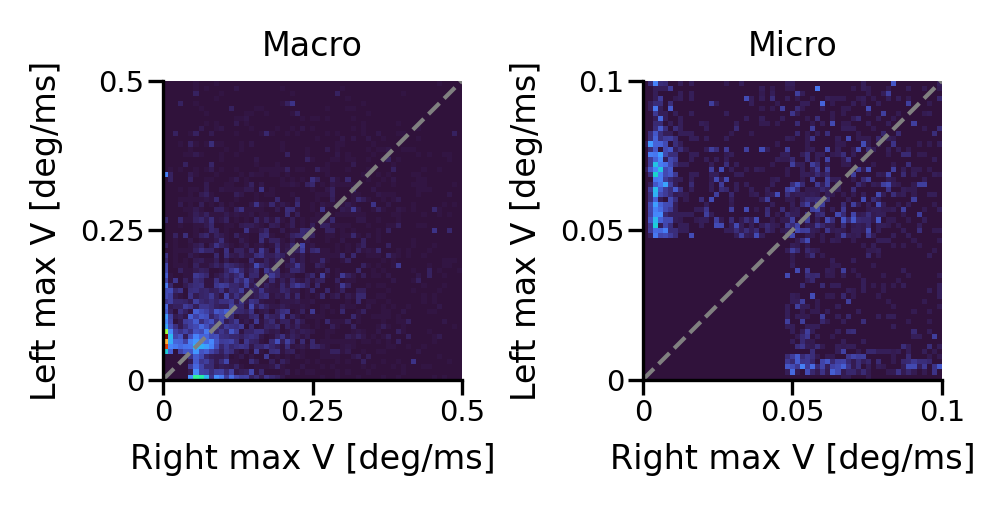

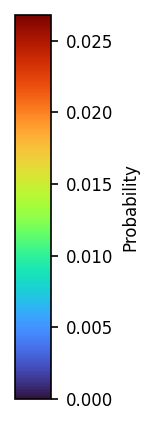

wrote 3 files under /Users/nimi/Projects/PETS/outputs/2f_colormap_trials/figure_2f_turbo_head_still
  figure_2f_turbo_head_still_colorbar_turbo.pdf
  figure_2f_turbo_head_still_colormap_trials.pickle
  figure_2f_turbo_head_still_turbo.pdf


In [4]:
# Turbo Fig 2f with require_head_stationary (same logic as paper Fig 2f).
lizard_turbo_head_still = export_2f_colormap_bundle(
    with_params(
        lizard_tables,
        {
            "figure_2f": {
                "require_head_stationary": True,
                "event_mode": "all",
            }
        },
    ),
    RUN,
    plot_id="figure_2f_turbo_head_still",
    figure_kind="2f",
    colormap_variants=("turbo",),
    show=True,
)
print(f"wrote {len(lizard_turbo_head_still)} files under {RUN / 'figure_2f_turbo_head_still'}")
for name in sorted(lizard_turbo_head_still):
    print(" ", name)


## 2. Export lizard Fig 2f (head-stationary, three colormaps)

[2f] head_stationary filter: 19212 → 6996
[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=4740 binocular_pairs=1556 monocular=3184 skip_mode=0 skip_profile=700 exclude=['PV_57', 'PV_62'] animals=['PV_106', 'PV_126', 'PV_143'] macro_range=[0.0, 0.5] micro_range=[0.0, 0.1]


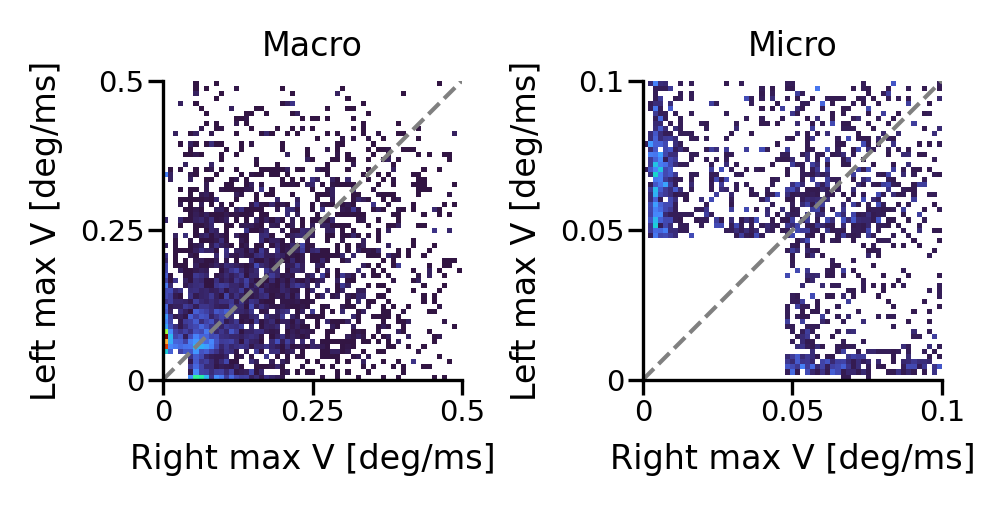

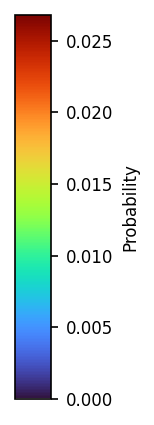

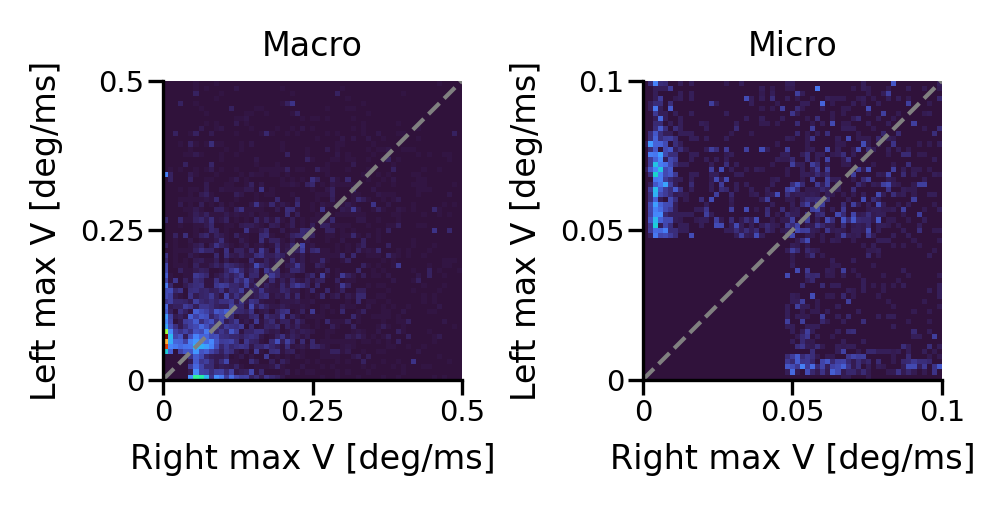

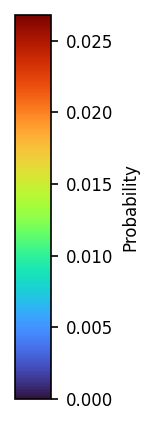

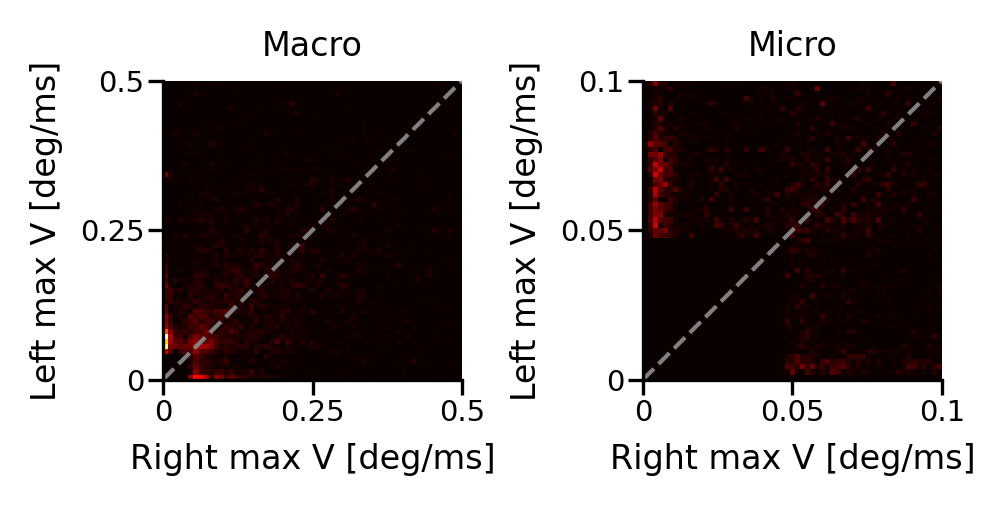

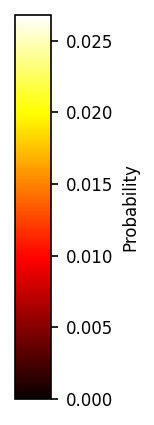

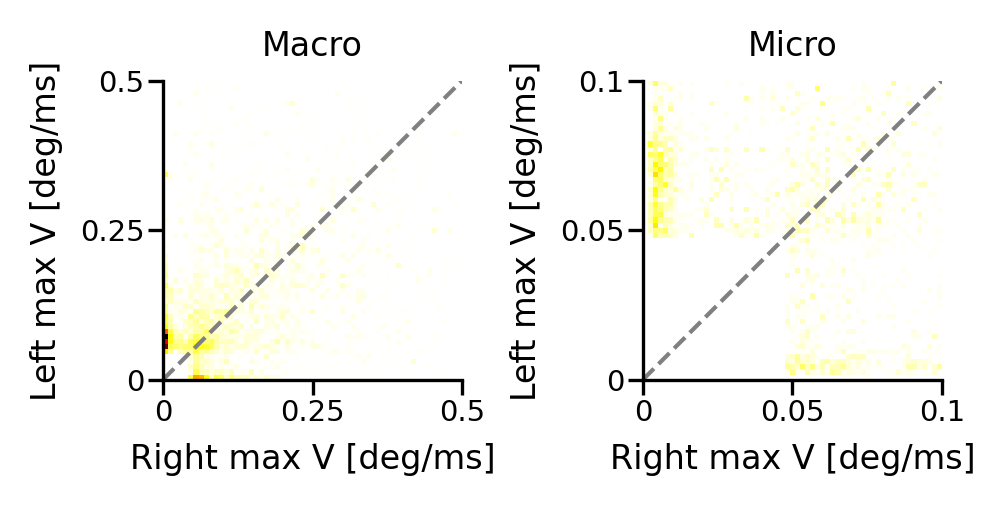

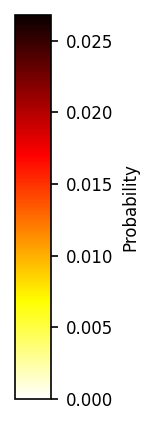

wrote 9 files under /Users/nimi/Projects/PETS/outputs/2f_colormap_trials/figure_2f
  figure_2f_colorbar_hot.pdf
  figure_2f_colorbar_hot_r.pdf
  figure_2f_colorbar_paper_white0.pdf
  figure_2f_colorbar_turbo.pdf
  figure_2f_colormap_trials.pickle
  figure_2f_hot.pdf
  figure_2f_hot_r.pdf
  figure_2f_paper_white0.pdf
  figure_2f_turbo.pdf


In [5]:
lizard_2f = export_2f_colormap_bundle(
    lizard_tables,
    RUN,
    plot_id="figure_2f",
    figure_kind="2f",
    show=True,
)
print(f"wrote {len(lizard_2f)} files under {RUN / 'figure_2f'}")
for name in sorted(lizard_2f):
    print(" ", name)

## 3. Export lizard Fig S3 (still vs moving, three colormaps)

[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=24092 binocular_pairs=9967 monocular=14125 skip_mode=0 skip_profile=2025 exclude=[] animals=['PV_106', 'PV_126', 'PV_143', 'PV_57', 'PV_62'] macro_range=[0.0, 0.5] micro_range=[0.0, 0.1]


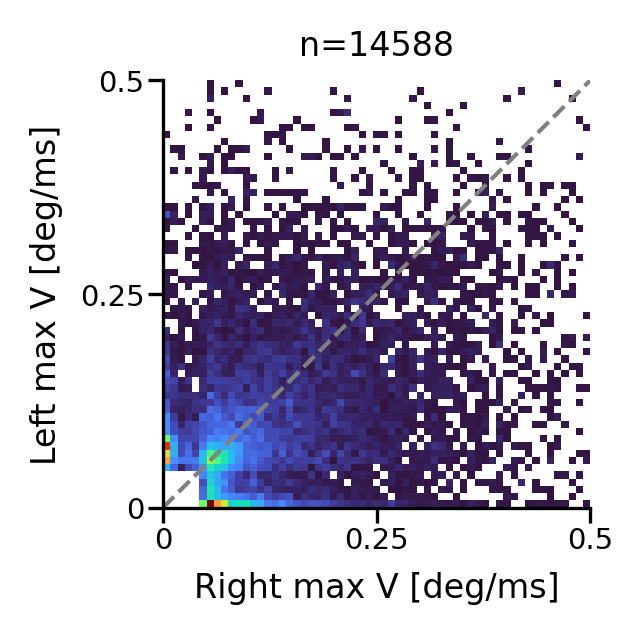

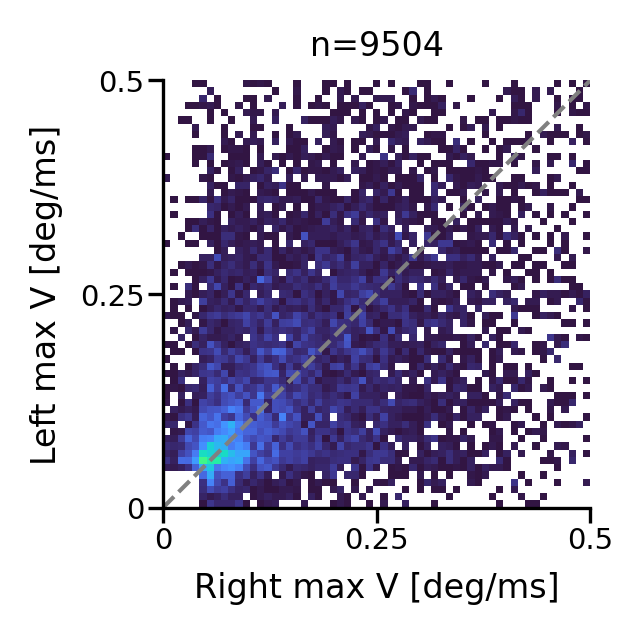

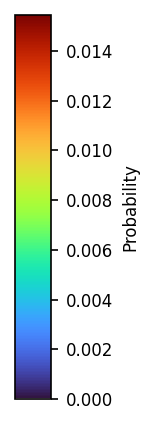

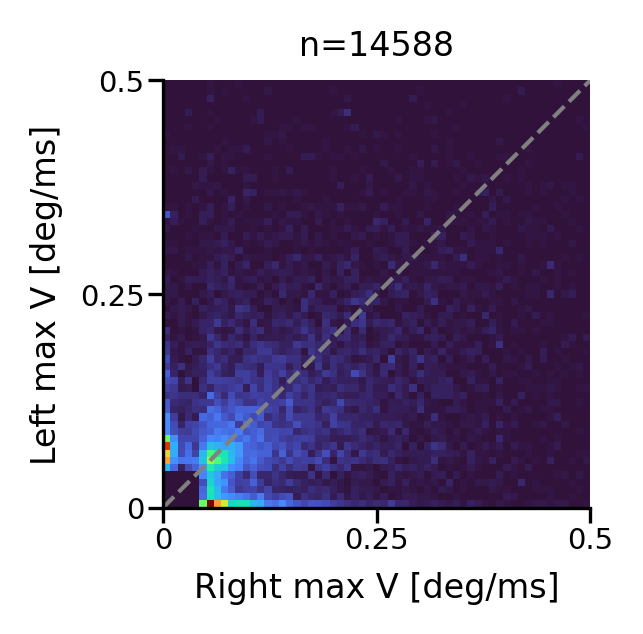

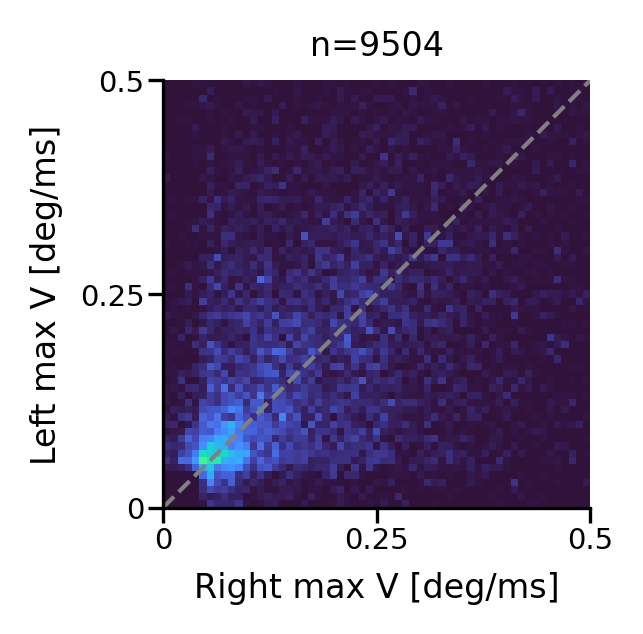

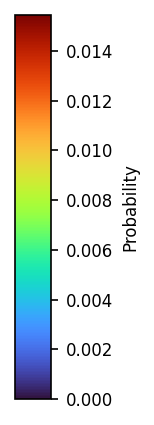

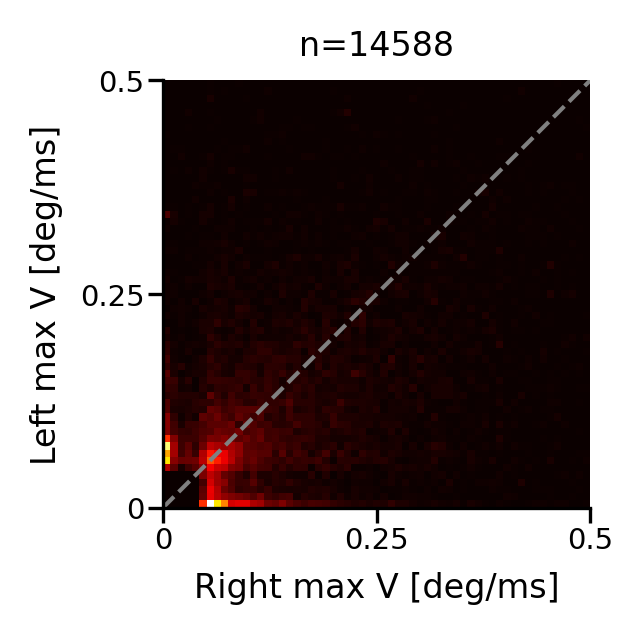

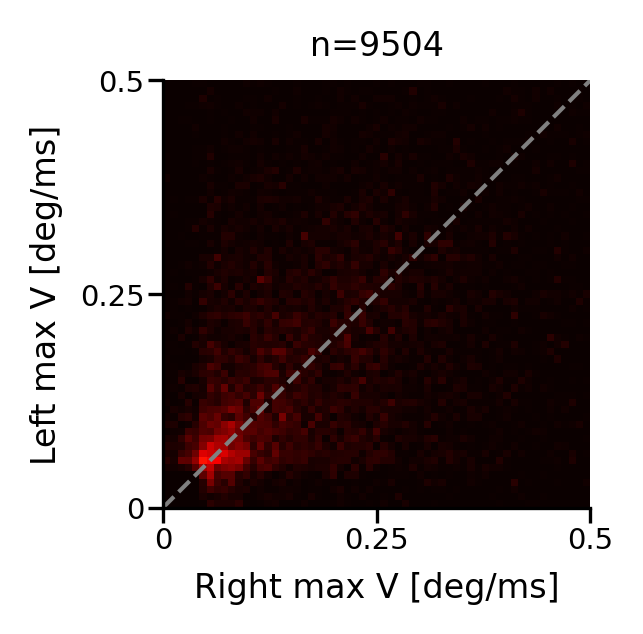

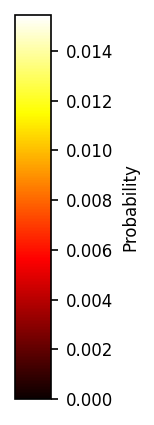

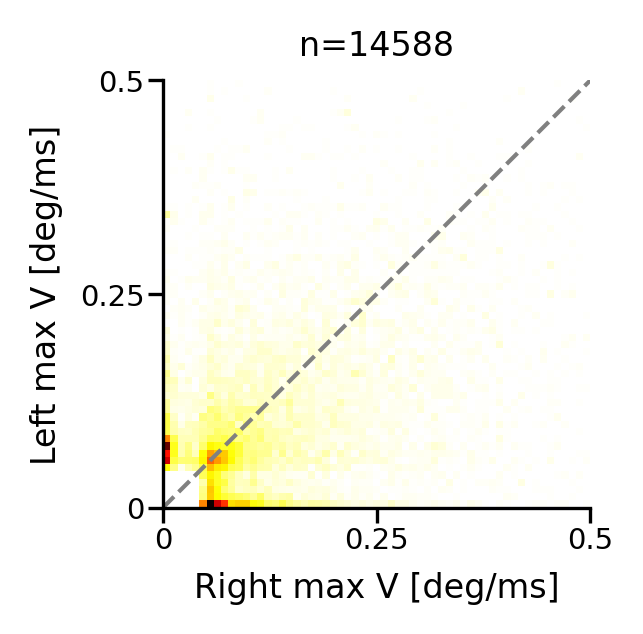

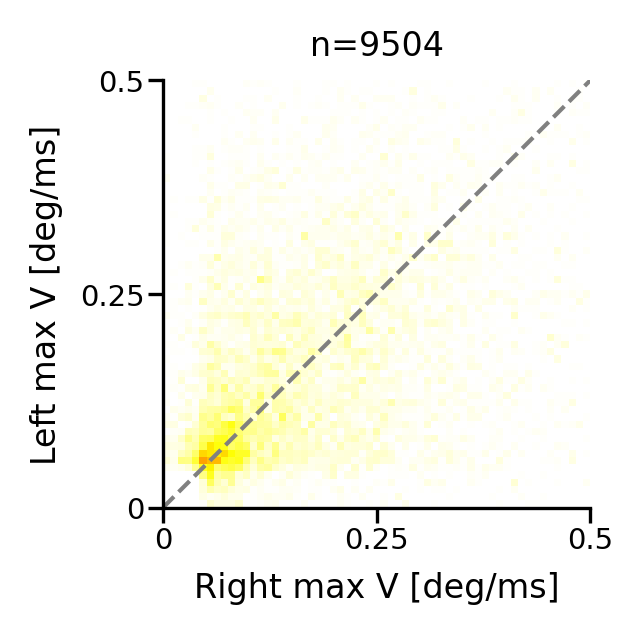

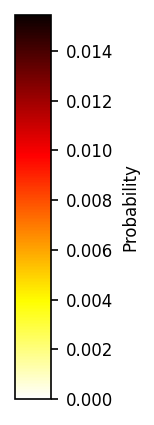

wrote 13 files under /Users/nimi/Projects/PETS/outputs/2f_colormap_trials/figure_S3
  figure_S3_colorbar_hot.pdf
  figure_S3_colorbar_hot_r.pdf
  figure_S3_colorbar_paper_white0.pdf
  figure_S3_colorbar_turbo.pdf
  figure_S3_colormap_trials.pickle
  figure_S3_head_moving_hot.pdf
  figure_S3_head_moving_hot_r.pdf
  figure_S3_head_moving_paper_white0.pdf
  figure_S3_head_moving_turbo.pdf
  figure_S3_head_still_hot.pdf
  figure_S3_head_still_hot_r.pdf
  figure_S3_head_still_paper_white0.pdf
  figure_S3_head_still_turbo.pdf


In [6]:
lizard_s3 = export_2f_colormap_bundle(
    lizard_tables,
    RUN,
    plot_id="figure_S3",
    figure_kind="s3",
    show=True,
)
print(f"wrote {len(lizard_s3)} files under {RUN / 'figure_S3'}")
for name in sorted(lizard_s3):
    print(" ", name)

## 4. Load mouse event tables (+ traces)

In [7]:
mouse_params = load_params_yaml(MOUSE_PARAMS)
mouse_specs = load_registry(MOUSE_REGISTRY)
mouse_tables, mouse_cache, mouse_from_cache = build_or_load_event_tables(
    mouse_specs,
    mouse_params,
    CACHE_DIR,
    keep_traces=True,
    prefer_finalized=True,
)
mouse_block_keys = [b.spec.block_key for b in mouse_tables.blocks]
mouse_tables = ensure_traces_for_blocks(mouse_tables, mouse_block_keys)
print(
    f"mouse blocks={len(mouse_tables.blocks)} events={len(mouse_tables.all_saccades)} "
    f"cache={'hit' if mouse_from_cache else 'miss'}"
)
print(mouse_cache)

[M_002_block_012] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
[M_002_block_013] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
[M_002_block_014] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
[M_002_block_015] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
mouse blocks=4 events=17585 cache=hit
/Users/nimi/Projects/PETS/outputs/2f_colormap_trials/metadata/event_cache/event_cache/c063f64cd1604c07c521dc977d99a9a697e4f86a.pkl


## 5. Export mouse Fig 2f (auto axis limits, three colormaps)

[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=12271 binocular_pairs=5168 monocular=7103 skip_mode=0 skip_profile=146 exclude=[] animals=['M_002'] macro_range=[0.0, 1.25] micro_range=[0.0, 0.25]


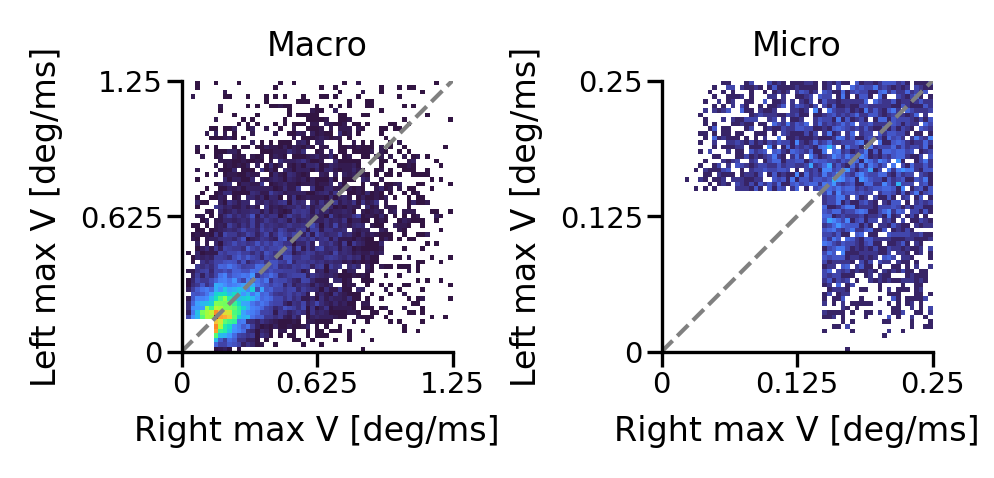

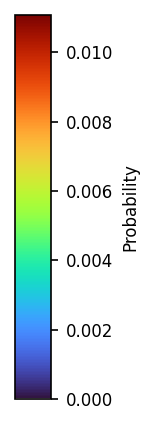

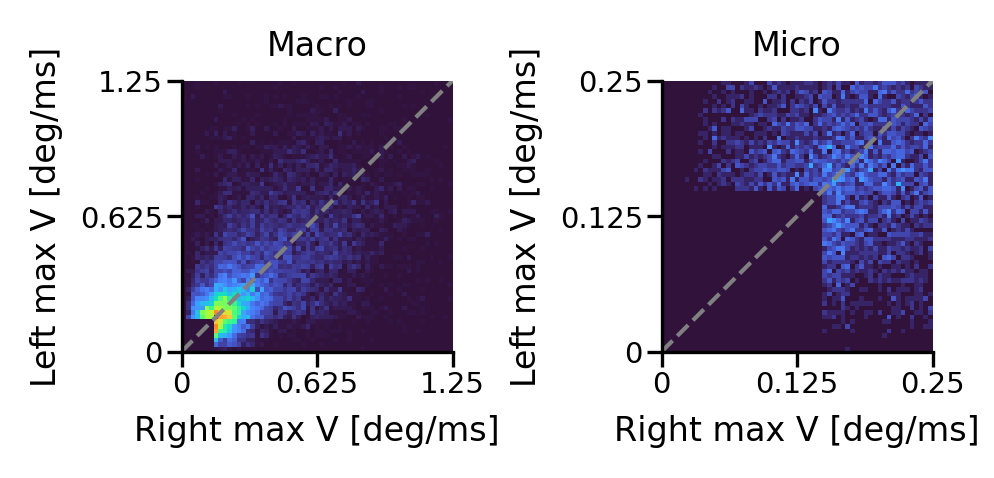

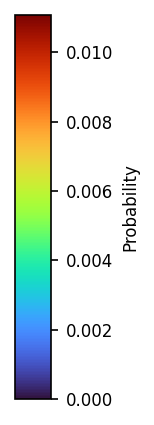

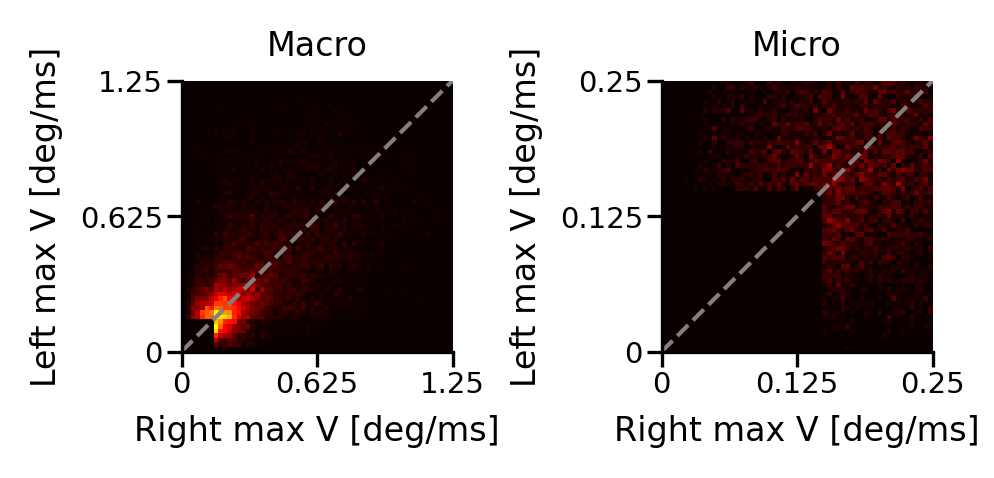

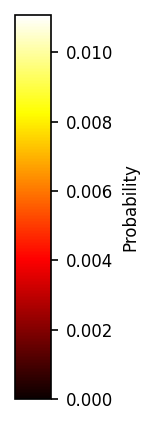

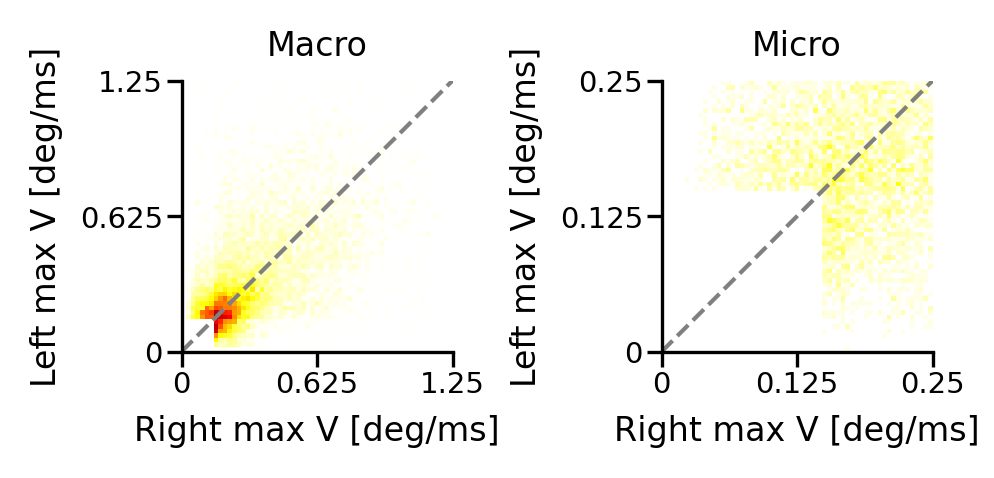

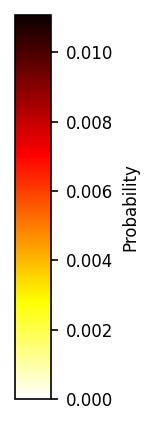

wrote 9 files under /Users/nimi/Projects/PETS/outputs/2f_colormap_trials/mouse_figure_2f
  mouse_figure_2f_colorbar_hot.pdf
  mouse_figure_2f_colorbar_hot_r.pdf
  mouse_figure_2f_colorbar_paper_white0.pdf
  mouse_figure_2f_colorbar_turbo.pdf
  mouse_figure_2f_colormap_trials.pickle
  mouse_figure_2f_hot.pdf
  mouse_figure_2f_hot_r.pdf
  mouse_figure_2f_paper_white0.pdf
  mouse_figure_2f_turbo.pdf


In [8]:
mouse_2f = export_2f_colormap_bundle(
    mouse_tables,
    RUN,
    plot_id="mouse_figure_2f",
    figure_kind="2f",
    cohort_override="mouse",
    show=True,
)
print(f"wrote {len(mouse_2f)} files under {RUN / 'mouse_figure_2f'}")
for name in sorted(mouse_2f):
    print(" ", name)

## 6. Verify exports

In [9]:
report = verify_colormap_trials_run(RUN)
print(json.dumps(report, indent=2))
print()
if report["all_complete"]:
    print(f"All bundles complete under {RUN}")
else:
    print("Some bundles incomplete — see missing_pdfs above.")
    for plot_id, info in report["bundles"].items():
        if info.get("missing_pdfs"):
            print(f"  {plot_id} missing:", info["missing_pdfs"])

{
  "run_dir": "/Users/nimi/Projects/PETS/outputs/2f_colormap_trials",
  "bundles": {
    "figure_2f": {
      "exists": true,
      "plots_dir": true,
      "metadata_dir": true,
      "replot_py": true,
      "logic_md": true,
      "pdfs": [
        "figure_2f_colorbar_hot.pdf",
        "figure_2f_colorbar_hot_r.pdf",
        "figure_2f_colorbar_paper_white0.pdf",
        "figure_2f_colorbar_turbo.pdf",
        "figure_2f_hot.pdf",
        "figure_2f_hot_r.pdf",
        "figure_2f_paper_white0.pdf",
        "figure_2f_turbo.pdf"
      ],
      "missing_pdfs": [],
      "complete": true
    },
    "mouse_figure_2f": {
      "exists": true,
      "plots_dir": true,
      "metadata_dir": true,
      "replot_py": true,
      "logic_md": true,
      "pdfs": [
        "mouse_figure_2f_colorbar_hot.pdf",
        "mouse_figure_2f_colorbar_hot_r.pdf",
        "mouse_figure_2f_colorbar_paper_white0.pdf",
        "mouse_figure_2f_colorbar_turbo.pdf",
        "mouse_figure_2f_hot.pdf",
        

## 7. Paper reproduction check (filters vs archived pickle)

Compare three collector paths against the archived `figure_2f_nodowncast.pickle` (1,724 points, 2026-01-09 export):

| Run | `event_mode` | `pairing_mode` | Intended match |
|-----|--------------|----------------|----------------|
| **Legacy notebook** | `monocular` | `legacy_contra_table` | Original `show_monocular_saccades` export |
| **Current paper path** | `all` | `synced_ms` | Caption logic (asymmetry from head-still only) |

Shared row filters: `require_head_stationary`, `exclude_animals: [PV_62, PV_57]`.


In [10]:
import pickle
from pprint import pprint

from eye_tracking_system_tools.analysis.figures_2f_2h_2i import (
    archived_figure_2f_pickle,
    collect_figure_2f_points,
    compare_figure_2f_to_reference,
    histogram2d_from_points,
    summarize_figure_2f_event_table,
    _draw_coupling_heatmap,
)
from eye_tracking_system_tools.analysis.figures_2f_colormap_export import (
    export_2f_colormap_bundle,
    resolve_figure_2f_colormap,
)

REF_PICKLE = Path(
    "/Volumes/Data-1/Nimrod/Paper_Figures/2024_Personalized_headstage_eye_tracking/"
    "Figure_3/materials/show_monocular_saccades/2026_01_09_11_35/fig_2f/"
    "figure_2f_nodowncast.pickle"
)
if not REF_PICKLE.exists():
    REF_PICKLE = archived_figure_2f_pickle(REPO)

PAPER_FILTERS = {
    "require_head_stationary": True,
    "exclude_animals": ["PV_62", "PV_57"],
    "iqr_multiplier": 60.0,
    "bins": 60,
    "macro_range": [0.0, 0.5],
    "micro_range": [0.0, 0.1],
    "macro_tick_list": [0.0, 0.25, 0.5],
    "micro_tick_list": [0.0, 0.05, 0.1],
    "contra_event_window_ms": 100.0,
    "contra_sample_ms": 51.0,
    "pair_merge_ms": 60.0,
}

print("=== Event table (before point collection) ===")
pprint(summarize_figure_2f_event_table(lizard_tables, PAPER_FILTERS))

print("\n=== A. Legacy notebook (monocular + legacy_contra_table) ===")
legacy = collect_figure_2f_points(
    lizard_tables,
    cfg={**PAPER_FILTERS, "event_mode": "monocular", "pairing_mode": "legacy_contra_table"},
)
report_legacy = compare_figure_2f_to_reference(legacy, REF_PICKLE)
pprint(report_legacy)

print("\n=== B. Current paper path (all + synced_ms) ===")
current = collect_figure_2f_points(
    lizard_tables,
    cfg={**PAPER_FILTERS, "event_mode": "all", "pairing_mode": "synced_ms"},
)
report_current = compare_figure_2f_to_reference(current, REF_PICKLE)
pprint(report_current)

REPRO_RUN = colormap_trials_run_dir(REPO / "outputs", "paper_repro")
export_2f_colormap_bundle(
    lizard_tables,
    REPRO_RUN,
    plot_id="figure_2f_paper_repro",
    figure_kind="2f",
    params_overrides={**PAPER_FILTERS, "event_mode": "all", "pairing_mode": "synced_ms"},
    colormap_variants=("paper_white0",),
    show=False,
)
print("\nExported paper-repro bundle:", REPRO_RUN / "figure_2f_paper_repro")


=== Event table (before point collection) ===
{'animals_in_registry': ['PV_106', 'PV_126', 'PV_143', 'PV_57', 'PV_62'],
 'exclude_animals': ['PV_57', 'PV_62'],
 'n_events_after_filters': 6996,
 'n_events_total': 36084,
 'per_animal': {'PV_106': {'n_after_filters': 2470,
                           'n_all': 6702,
                           'n_head_nan': 0,
                           'n_moving': 4232,
                           'n_still': 2470},
                'PV_126': {'n_after_filters': 3491,
                           'n_all': 9198,
                           'n_head_nan': 0,
                           'n_moving': 5707,
                           'n_still': 3491},
                'PV_143': {'n_after_filters': 1035,
                           'n_all': 3312,
                           'n_head_nan': 0,
                           'n_moving': 2277,
                           'n_still': 1035},
                'PV_57': {'n_after_filters': 0,
                          'n_all': 11088,
       

## 7b. Paper-style Fig 2f (head-still + monocular only)

Archived paper export (2026-01-09) used **head-stationary** rows and **`event_mode=monocular`**
(no contra saccade onset within ±100 ms), with PV_62 and PV_57 excluded. Contra-eye speed
still comes from the ±51 ms trace window — so high–high points are expected even under
monocular filtering.

Exports **`turbo`** and **`paper_white0`** colormap variants into the same run folder.


In [ ]:
PAPER_MONOCULAR_FILTERS = {
    "require_head_stationary": True,
    "exclude_animals": ["PV_62", "PV_57"],
    "event_mode": "monocular",
    "pairing_mode": "legacy_contra_table",
    "contra_event_window_ms": 100.0,
    "contra_sample_ms": 51.0,
    "pair_merge_ms": 60.0,
    "iqr_multiplier": 60.0,
    "bins": 60,
    "macro_range": [0.0, 0.5],
    "micro_range": [0.0, 0.1],
    "macro_tick_list": [0.0, 0.25, 0.5],
    "micro_tick_list": [0.0, 0.05, 0.1],
}

paper_mono = export_2f_colormap_bundle(
    lizard_tables,
    RUN,
    plot_id="figure_2f_paper_monocular",
    figure_kind="2f",
    params_overrides=PAPER_MONOCULAR_FILTERS,
    colormap_variants=("paper_white0", "turbo"),
    show=True,
)

print(f"Paper-style monocular export → {RUN / 'figure_2f_paper_monocular'}")
print(f"Wrote {len(paper_mono)} files:")
for name in sorted(paper_mono):
    print(" ", name)


## 8. Diagnostic grid — per animal × head filter

Each row is one animal; columns are **all** events, **head-stationary** (`head_movement == False`), and **head-moving** (`head_movement == True`). Macro panel only (`event_mode=all`, synced pairing). NaN head labels (PV_57) leave the still/moving columns empty.


[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=4596 binocular_pairs=1814 monocular=2782 skip_mode=0 skip_profile=292 exclude=['PV_126', 'PV_143', 'PV_57', 'PV_62'] animals=['PV_106'] macro_range=[0.0, 0.5] micro_range=[0.0, 0.1]
[2f] head_stationary filter: 6702 → 2470
[2f] head_still filter: 2470 → 2470
[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=1877 binocular_pairs=367 monocular=1510 skip_mode=0 skip_profile=226 exclude=['PV_126', 'PV_143', 'PV_57', 'PV_62'] animals=['PV_106'] macro_range=[0.0, 0.5] micro_range=[0.0, 0.1]
[2f] head_moving filter: 6702 → 4232
[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=2826 binocular_pairs=1340 monocular=1486 skip_mode=0 skip_profile=66 exclude=['PV_126', 'PV_143', 'PV_57', 'PV_62'] animals=['PV_106'] macro_range=[0.0, 0.5] micro_range=[0.0, 0.1]
[2f] pairing_mode=synced_ms event_mode=all sample_mode=contra_window kept=5862 binocular_pairs=2818 monocular=3044 skip_

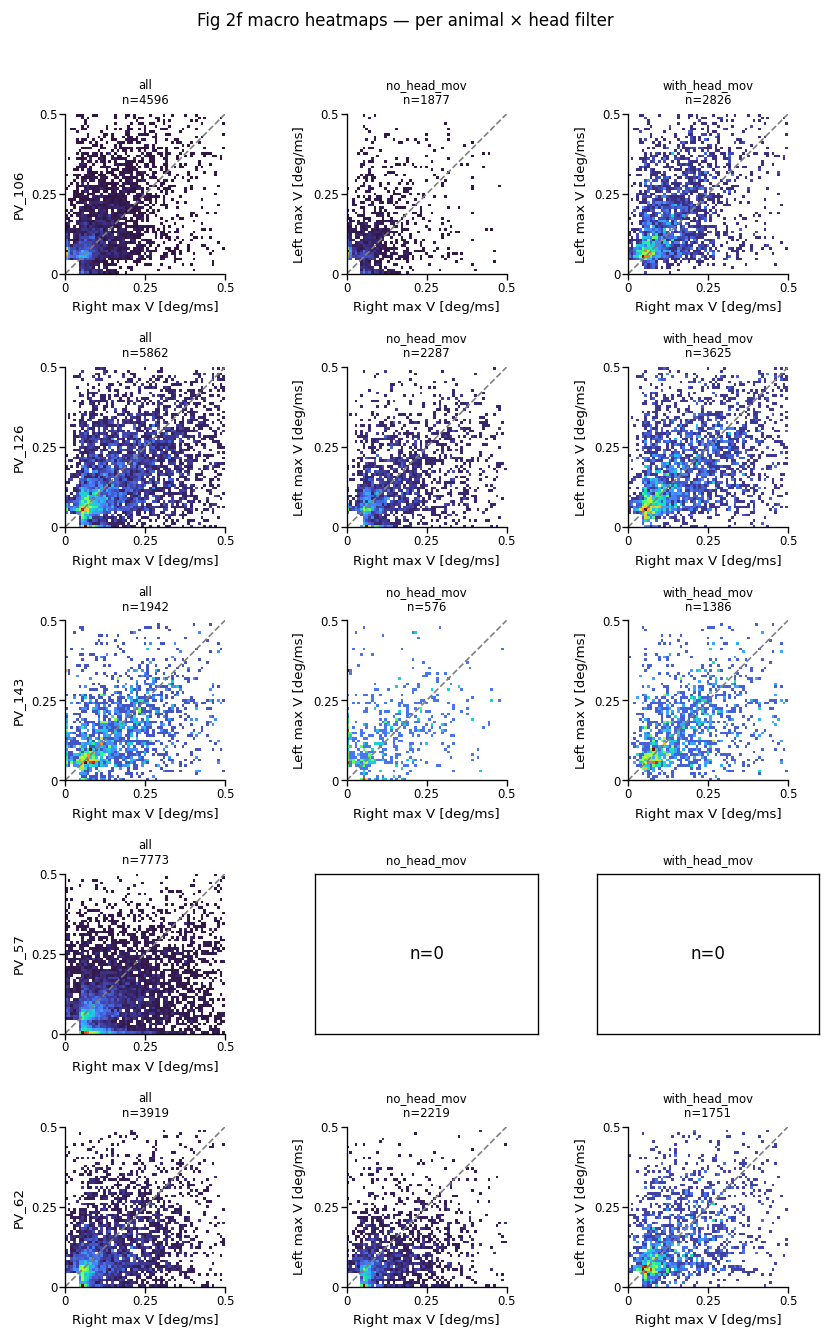

In [11]:
import numpy as np

ANIMALS = sorted(lizard_tables.all_saccades["animal"].astype(str).unique())
HEAD_COLS = [
    ("all", {"require_head_stationary": False, "head_filter": "all"}),
    ("no_head_mov", {"require_head_stationary": True, "head_filter": "still"}),
    ("with_head_mov", {"require_head_stationary": False, "head_filter": "moving"}),
]
BASE_CFG = {
    "event_mode": "all",
    "pairing_mode": "synced_ms",
    "exclude_animals": [],
    "bins": 60,
    "macro_range": [0.0, 0.5],
    "micro_range": [0.0, 0.1],
    "macro_tick_list": [0.0, 0.25, 0.5],
    "micro_tick_list": [0.0, 0.05, 0.1],
    "auto_view_limits": False,
}

cmap = resolve_figure_2f_colormap("paper_white0")
n_rows, n_cols = len(ANIMALS), len(HEAD_COLS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 2.2 * n_rows), dpi=120)
if n_rows == 1:
    axes = np.asarray([axes])
if n_cols == 1:
    axes = axes.reshape(-1, 1)

for ri, animal in enumerate(ANIMALS):
    for ci, (col_label, head_kw) in enumerate(HEAD_COLS):
        ax = axes[ri, ci]
        cfg = {
            **BASE_CFG,
            **head_kw,
            "exclude_animals": [a for a in ANIMALS if a != animal],
        }
        try:
            collected = collect_figure_2f_points(lizard_tables, cfg=cfg)
            hist = histogram2d_from_points(collected, view="macro")
            vmax = float(np.nanmax(hist["norm_counts"])) or 1.0
            _draw_coupling_heatmap(
                ax,
                hist,
                collected.macro_range,
                collected.cfg.get("macro_tick_list"),
                vmax=vmax,
                cmap=cmap,
            )
            ax.set_title(f"{col_label}\nn={len(collected.points)}", fontsize=7)
        except ValueError:
            ax.text(0.5, 0.5, "n=0", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(col_label, fontsize=7)
        if ci == 0:
            ax.set_ylabel(animal, fontsize=8)

fig.suptitle("Fig 2f macro heatmaps — per animal × head filter", fontsize=10, y=1.01)
fig.tight_layout()
plt.show()


### Reproduction report (auto-generated summary)

After running §7, check `outputs/2f_colormap_trials_paper_repro_*/metadata/reproduction_report.json`.

**Expected findings (2026-08-30 remount):**

| Metric | Archived pickle (2026-01-09) | Legacy monocular remount | Current `all` + synced |
|--------|------------------------------|--------------------------|-------------------------|
| Input rows (head-still, excl. 62/57) | 6,682 | ~6,996 (+314) | ~6,996 |
| Final 2f points | **1,724** | ~2,262 (+31%) | ~4,740 |
| Animals | PV_106, PV_143, PV_126 | same 3 | same 3 |

**Interference factors:**

1. **Larger event table** — remount has 36,084 saccade rows vs ~28,146 in the paper Fig 2j pickle (+28%).
2. **Animal exclusions** — PV_62 (unreliable head labels) and PV_57 (no lizMov.mat) now applied in `analysis_params.yaml`.
3. **Event-mode philosophy** — archived export used explicit `monocular` filter; current paper path uses `event_mode=all` so binocular pairs add a diagonal ridge (~1,556 pairs).
4. **Exact pickle match** — use `export_archived_figure_2f()` or replot from the archived pickle for pixel-identical reproduction.
